<a href="https://colab.research.google.com/github/toanhuynh040805-crypto/DeepLearning_DuDoanGiaNha/blob/main/BaiTaoNhomDT1_THDeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Thông tin tổng quan về tập dữ liệu ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None

--- Số lượng giá trị bị khuyết trong mỗi cột ---
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population             

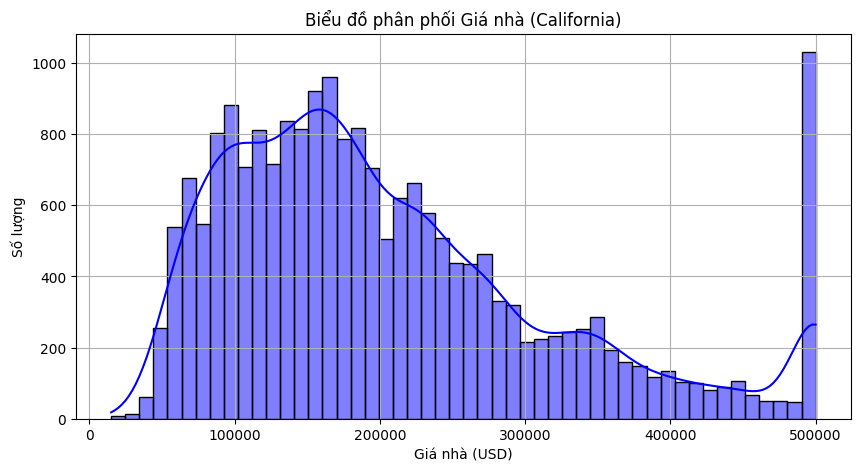

In [2]:
#1: Khám phá & Phân tích dữ liệu (EDA)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Đọc dữ liệu
df = pd.read_csv('/content/sample_data/housing.csv')

# 2. Xem thông tin tổng quan về các cột và kiểu dữ liệu
print("--- Thông tin tổng quan về tập dữ liệu ---")
print(df.info())

# 3. Kiểm tra số lượng dòng bị khuyết dữ liệu (Missing Values)
print("\n--- Số lượng giá trị bị khuyết trong mỗi cột ---")
print(df.isnull().sum())

# 4. Vẽ biểu đồ phân phối của giá nhà (Biến mục tiêu)
plt.figure(figsize=(10, 5))
sns.histplot(df['median_house_value'], kde=True, color='blue', bins=50)
plt.title('Biểu đồ phân phối Giá nhà (California)')
plt.xlabel('Giá nhà (USD)')
plt.ylabel('Số lượng')
plt.grid(True)
plt.show()

In [3]:
#2: Tiền xử lý dữ liệu (Data Preprocessing)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Xử lý giá trị khuyết bằng cách điền giá trị trung vị (Median)
median_bedrooms = df['total_bedrooms'].median()
df['total_bedrooms'] = df['total_bedrooms'].fillna(median_bedrooms)

# 2. Mã hóa biến phân loại 'ocean_proximity' thành các cột số (0 và 1)
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

# 3. Tách Đặc trưng (X) và Nhãn/Giá nhà (y)
# Bây giờ X sẽ bao gồm tất cả các cột trừ cột giá nhà 'median_house_value'
X = df.drop(columns=['median_house_value']).values
y = df['median_house_value'].values

# 4. Chia dữ liệu thành tập Huấn luyện (80%) và Kiểm tra (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Chuẩn hóa dữ liệu đầu vào (Standardization)
# Đưa tất cả dữ liệu về cùng một phân phối có trung bình bằng 0, độ lệch chuẩn bằng 1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nKích thước tập Train: {X_train_scaled.shape}")
print(f"Kích thước tập Test: {X_test_scaled.shape}")


Kích thước tập Train: (16512, 12)
Kích thước tập Test: (4128, 12)


In [4]:
#3: Thiết kế & Huấn luyện mạng ANN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 1. Định nghĩa cấu trúc mạng ANN
model = Sequential([
    # Lớp ẩn 1: 128 nút. Input_shape tự động lấy theo số lượng đặc trưng sau khi mã hóa
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.1), # Tránh quá khớp (Overfitting) bằng cách tắt ngẫu nhiên 10% nút

    # Lớp ẩn 2: 64 nút
    Dense(64, activation='relu'),

    # Lớp ẩn 3: 32 nút
    Dense(32, activation='relu'),

    # Lớp ẩn 4: 16 nút
    Dense(16, activation='relu'),

    # Lớp đầu ra (Output): 1 nút dự đoán giá trị liên tục
    Dense(1)
])

# 2. Biên dịch mô hình (Compile)
# Sử dụng Adam Optimizer và hàm mất mát MSE theo đúng yêu cầu đề tài
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.002),
    loss='mse',
    metrics=['mae'] # Theo dõi thêm chỉ số MAE trong quá trình học
)

# 3. Huấn luyện mô hình (Training)
print("\n--- Bắt đầu huấn luyện mạng ANN ---")
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2, # Trích 20% tập train làm tập validation để kiểm tra độ lỗi qua từng epoch
    epochs=80,            # Số lượt duyệt qua toàn bộ tập dữ liệu
    batch_size=32,        # Kích thước gói dữ liệu cập nhật trọng số
    verbose=1
)


--- Bắt đầu huấn luyện mạng ANN ---
Epoch 1/80


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 24268032000.0000 - mae: 115202.7422 - val_loss: 6537166336.0000 - val_mae: 57697.4336
Epoch 2/80
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 5517981184.0000 - mae: 52954.0430 - val_loss: 5289437184.0000 - val_mae: 53153.4336
Epoch 3/80
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4826541568.0000 - mae: 49723.5430 - val_loss: 4867672576.0000 - val_mae: 50455.4180
Epoch 4/80
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4605629440.0000 - mae: 48636.6680 - val_loss: 4709661696.0000 - val_mae: 48859.1523
Epoch 5/80
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4496650240.0000 - mae: 47872.6602 - val_loss: 4638688256.0000 - val_mae: 48008.2891
Epoch 6/80
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4406709248.0000 - mae: 47339.1406 - val_loss: 4593609728.0000 - val_mae: 47395.0117
Epoch 7/80
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4379349504.0000 - mae: 47000.9102 - val_loss: 4593152000.0000 - val_mae: 48754.2070
E

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

================ KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ================
1. Mean Absolute Error (MAE): $44,086.23 USD
2. Mean Squared Error (MSE) : 4,003,168,396.26
3. Root Mean Squared Error (RMSE): $63,270.60 USD


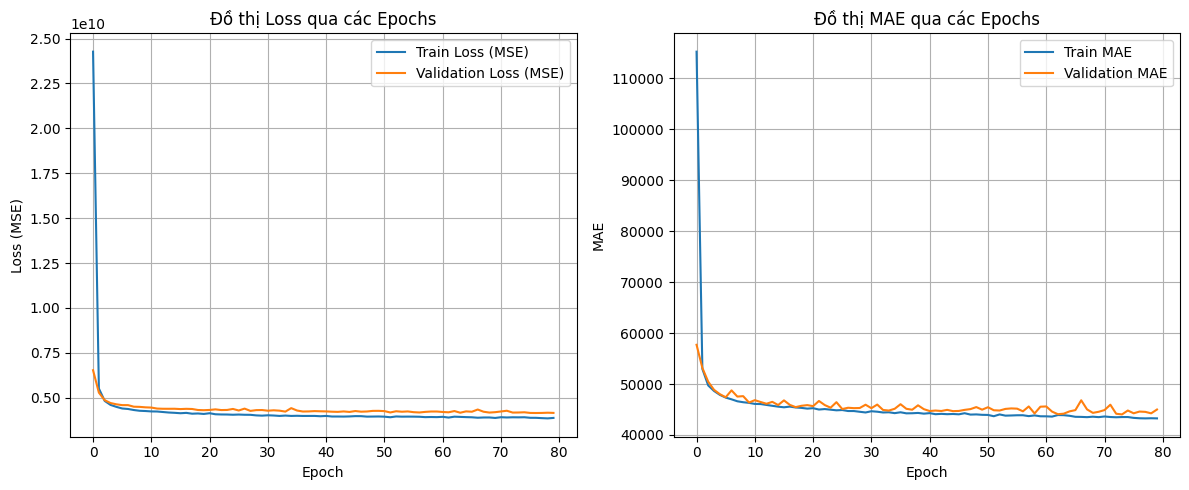


Bảng so sánh ngẫu nhiên 5 kết quả đầu tiên:
 Giá thực tế (USD)  Giá dự đoán (USD)
           47700.0       55634.550781
           45800.0      152183.312500
          500001.0      462617.500000
          218600.0      270957.843750
          278000.0      304010.937500


In [5]:
#4: Đánh giá mô hình & Trực quan hóa kết quả
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Dự đoán trên tập dữ liệu kiểm tra (Test set)
y_pred = model.predict(X_test_scaled).flatten()

# 2. Tính toán các chỉ số lỗi MAE, MSE, RMSE
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\n================ KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ================")
print(f"1. Mean Absolute Error (MAE): ${mae:,.2f} USD")
print(f"2. Mean Squared Error (MSE) : {mse:,.2f}")
print(f"3. Root Mean Squared Error (RMSE): ${rmse:,.2f} USD")
print("==========================================================")

# 3. Vẽ đồ thị Lịch sử huấn luyện (Loss Curve)
plt.figure(figsize=(12, 5))

# Đồ thị Loss (MSE)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Đồ thị Loss qua các Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

# Đồ thị MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Đồ thị MAE qua các Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 4. Xuất thử 5 căn nhà thực tế so với dự đoán để kiểm tra trực quan
df_compare = pd.DataFrame({'Giá thực tế (USD)': y_test, 'Giá dự đoán (USD)': y_pred})
print("\nBảng so sánh ngẫu nhiên 5 kết quả đầu tiên:")
print(df_compare.head(5).to_string(index=False))

In [6]:
#Lưu (Export) Mô hình và Bộ chuẩn hóa từ Colab
# Lưu mô hình ANN thành file định dạng Keras (.h5 hoặc .keras)
model.save('ann_house_model.h5')

# Lưu bộ chuẩn hóa dữ liệu StandardScaler (sử dụng thư viện pickle)
import pickle
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Đã lưu thành công 2 file: 'ann_house_model.h5' và 'scaler.pkl'. Hãy tải chúng về máy tính của bạn!")

Đã lưu thành công 2 file: 'ann_house_model.h5' và 'scaler.pkl'. Hãy tải chúng về máy tính của bạn!
